# Setup and imports

In [1]:
!pip install torch-geometric -q
#!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.1.0+cpu.html -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.5 MB/s eta 0:00:00


In [2]:
# ============================================================================
# SETUP: Instalar dependencias
# ============================================================================



import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# # Configurar dispositivo
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Device: {device}")

# # Verificar GPU
# if torch.cuda.is_available():
#     print(f"GPU: {torch.cuda.get_device_name(0)}")
#     print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

In [10]:
# Configurar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


# Load graphs

In [15]:
# ============================================================================
# CARGAR GRAFOS GENERADOS
# ============================================================================

GRAPHS_FILE = '/content/drive/MyDrive/nids-mitre/data/cicids2018-v3/graph_data_DYNAMIC/graphs_dynamic_FIXED_v2.pkl'

print("Cargando grafos...")
start = time.time()

graphs = []

with open(GRAPHS_FILE, 'rb') as f:
    while True:
        try:
            graph = pickle.load(f)
            graphs.append(graph)
        except EOFError:
            break

print(f"✅ Cargados {len(graphs)} grafos en {time.time()-start:.1f}s")

# Verificar primer grafo
g = graphs[0]
print(f"\n📊 Ejemplo de grafo:")
print(f"   Window ID: {g.window_id}")
print(f"   Nodes: {g.num_nodes}")
print(f"   Edges: {g.edge_index.shape[1]}")
print(f"   Node features: {g.x.shape}")
print(f"   Edge features: {g.edge_attr.shape}")
print(f"   Label: {g.y.item()}")

Cargando grafos...
✅ Cargados 710 grafos en 27.5s

📊 Ejemplo de grafo:
   Window ID: 0
   Nodes: 2351
   Edges: 7851
   Node features: torch.Size([2351, 18])
   Edge features: torch.Size([7851, 37])
   Label: 0


# Split train/val/test

In [ ]:
# ============================================================================
# SPLIT TEMPORAL
# ============================================================================

# Ordenar por window_id
graphs_sorted = sorted(graphs, key=lambda g: g.window_id)

n = len(graphs_sorted)
train_end = int(0.70 * n)  # 70%
val_end = int(0.85 * n)    # 15%

train_graphs = graphs_sorted[:train_end]
val_graphs = graphs_sorted[train_end:val_end]
test_graphs = graphs_sorted[val_end:]

print("="*70)
print("📊 SPLIT TEMPORAL")
print("="*70)

def print_split_stats(split_name, split_graphs):
    normal = sum(1 for g in split_graphs if g.y.item() == 0)
    attack = sum(1 for g in split_graphs if g.y.item() == 1)

    print(f"\n{split_name}:")
    print(f"   Total:  {len(split_graphs)}")
    print(f"   Normal: {normal} ({normal/len(split_graphs)*100:.1f}%)")
    print(f"   Attack: {attack} ({attack/len(split_graphs)*100:.1f}%)")
    print(f"   Window range: {split_graphs[0].window_id} → {split_graphs[-1].window_id}")

print_split_stats("TRAIN", train_graphs)
print_split_stats("VAL", val_graphs)
print_split_stats("TEST", test_graphs)

# Verificar no-leakage
assert train_graphs[-1].window_id < val_graphs[0].window_id, "❌ Train/Val overlap!"
assert val_graphs[-1].window_id < test_graphs[0].window_id, "❌ Val/Test overlap!"
print("\n✅ No temporal leakage (splits are sequential)")

## Stratified split

In [16]:
# ============================================================================
# SPLIT ESTRATIFICADO TEMPORAL (RECOMENDADO)
# ============================================================================

print("="*70)
print("📊 SPLIT TEMPORAL ESTRATIFICADO")
print("="*70)

# Ordenar por window_id
graphs_sorted = sorted(graphs, key=lambda g: g.window_id)

# Separar por clase (preservando orden)
normal_graphs = [g for g in graphs_sorted if g.y.item() == 0]
attack_graphs = [g for g in graphs_sorted if g.y.item() == 1]

print(f"\nDataset completo:")
print(f"   Total:  {len(graphs_sorted)}")
print(f"   Normal: {len(normal_graphs)} ({len(normal_graphs)/len(graphs_sorted)*100:.1f}%)")
print(f"   Attack: {len(attack_graphs)} ({len(attack_graphs)/len(graphs_sorted)*100:.1f}%)")

# Split temporal dentro de cada clase
def temporal_split(graphs, train_pct=0.70, val_pct=0.15):
    """Split temporal preservando orden"""
    n = len(graphs)
    train_end = int(train_pct * n)
    val_end = int((train_pct + val_pct) * n)

    return (
        graphs[:train_end],           # 70%
        graphs[train_end:val_end],    # 15%
        graphs[val_end:]              # 15%
    )

train_normal, val_normal, test_normal = temporal_split(normal_graphs)
train_attack, val_attack, test_attack = temporal_split(attack_graphs)

# Combinar y re-ordenar por window_id
train_graphs = sorted(train_normal + train_attack, key=lambda g: g.window_id)
val_graphs = sorted(val_normal + val_attack, key=lambda g: g.window_id)
test_graphs = sorted(test_normal + test_attack, key=lambda g: g.window_id)

print("\n" + "="*70)
print("✅ SPLITS CREADOS")
print("="*70)

for name, split in [("TRAIN", train_graphs), ("VAL", val_graphs), ("TEST", test_graphs)]:
    normal = sum(1 for g in split if g.y.item() == 0)
    attack = sum(1 for g in split if g.y.item() == 1)

    print(f"\n{name}:")
    print(f"   Total:  {len(split)}")
    print(f"   Normal: {normal} ({normal/len(split)*100:.1f}%)")
    print(f"   Attack: {attack} ({attack/len(split)*100:.1f}%)")
    print(f"   Window range: {split[0].window_id} → {split[-1].window_id}")

print("\n✅ Orden temporal preservado DENTRO de cada split")
print("✅ Distribuciones balanceadas ENTRE splits")

📊 SPLIT TEMPORAL ESTRATIFICADO

Dataset completo:
   Total:  710
   Normal: 441 (62.1%)
   Attack: 269 (37.9%)

✅ SPLITS CREADOS

TRAIN:
   Total:  496
   Normal: 308 (62.1%)
   Attack: 188 (37.9%)
   Window range: 0 → 2169

VAL:
   Total:  106
   Normal: 66 (62.3%)
   Attack: 40 (37.7%)
   Window range: 1323 → 2209

TEST:
   Total:  108
   Normal: 67 (62.0%)
   Attack: 41 (38.0%)
   Window range: 1949 → 2349

✅ Orden temporal preservado DENTRO de cada split
✅ Distribuciones balanceadas ENTRE splits


# Normalize

In [17]:
# ============================================================================
# CELDA 2.5: NORMALIZAR FEATURES (CRÍTICO)
# ============================================================================

print("📊 Normalizando features de nodos y edges...")

import torch

# Calcular estadísticas de TRAIN ONLY (para evitar data leakage)
all_node_features = []
all_edge_features = []

for g in train_graphs:
    all_node_features.append(g.x)
    if g.edge_attr is not None:
        all_edge_features.append(g.edge_attr)

# Concatenar
X_train = torch.cat(all_node_features, dim=0)  # [total_nodes, 18]
E_train = torch.cat(all_edge_features, dim=0)  # [total_edges, 37]

# Calcular mean y std
node_mean = X_train.mean(dim=0)
node_std = X_train.std(dim=0) + 1e-6  # Evitar división por 0

edge_mean = E_train.mean(dim=0)
edge_std = E_train.std(dim=0) + 1e-6

print(f"✅ Estadísticas calculadas:")
print(f"   Node features: mean={node_mean[:5]}")
print(f"   Node features: std={node_std[:5]}")
print(f"   Edge features: mean={edge_mean[:5]}")
print(f"   Edge features: std={edge_std[:5]}")

# Función para normalizar
def normalize_graph(graph, node_mean, node_std, edge_mean, edge_std):
    from torch_geometric.data import Data

    normalized = Data()

    # Normalizar nodos: (x - mean) / std
    normalized.x = (graph.x - node_mean) / node_std

    # Normalizar edges
    if graph.edge_attr is not None:
        normalized.edge_attr = (graph.edge_attr - edge_mean) / edge_std
    else:
        normalized.edge_attr = None

    # Copiar el resto
    normalized.edge_index = graph.edge_index
    normalized.y = graph.y

    return normalized

# Normalizar todos los grafos
print("\n🔄 Normalizando grafos...")

train_graphs_norm = [normalize_graph(g, node_mean, node_std, edge_mean, edge_std)
                     for g in train_graphs]
val_graphs_norm = [normalize_graph(g, node_mean, node_std, edge_mean, edge_std)
                   for g in val_graphs]
test_graphs_norm = [normalize_graph(g, node_mean, node_std, edge_mean, edge_std)
                    for g in test_graphs]

print(f"✅ Grafos normalizados:")
print(f"   Train: {len(train_graphs_norm)}")
print(f"   Val:   {len(val_graphs_norm)}")
print(f"   Test:  {len(test_graphs_norm)}")

# Verificar normalización
g_norm = train_graphs_norm[0]
print(f"\n🔍 Features normalizadas (primeros 5 valores):")
print(f"   Node features: {g_norm.x[0, :5]}")
print(f"   Edge features: {g_norm.edge_attr[0, :5] if g_norm.edge_attr is not None else 'None'}")
print(f"   (Deberían estar cerca de 0 con std ~1)")

📊 Normalizando features de nodos y edges...
✅ Estadísticas calculadas:
   Node features: mean=tensor([3.0053e+01, 1.5067e+01, 1.5067e+01, 8.5815e+04, 4.0946e+04])
   Node features: std=tensor([5.9128e+02, 2.2408e+02, 5.4592e+02, 2.1909e+06, 1.3098e+07])
   Edge features: mean=tensor([1.3188e+04, 2.7640e+04, 2.5728e+00, 1.8607e+02, 4.0335e+01])
   Edge features: std=tensor([2.4464e+06, 1.1919e+06, 9.2524e+00, 4.0019e+04, 3.9008e+03])

🔄 Normalizando grafos...
✅ Grafos normalizados:
   Train: 496
   Val:   106
   Test:  108

🔍 Features normalizadas (primeros 5 valores):
   Node features: tensor([ 0.3534,  0.9993,  0.4102, -0.0392,  0.0047])
   Edge features: tensor([ 0.0366, -0.0232, -0.2781,  0.0156, -0.0103])
   (Deberían estar cerca de 0 con std ~1)


# Dataloader (batch of graphs)

In [18]:
# ============================================================================
# CELDA 3.5: LIMPIAR GRAFOS NORMALIZADOS
# ============================================================================

print("🧹 Limpiando grafos normalizados...")

from torch_geometric.data import Data

def clean_graph(graph):
    clean = Data()
    clean.x = graph.x
    clean.edge_index = graph.edge_index
    clean.edge_attr = graph.edge_attr
    clean.y = graph.y
    return clean

train_graphs_clean = [clean_graph(g) for g in train_graphs_norm]
val_graphs_clean = [clean_graph(g) for g in val_graphs_norm]
test_graphs_clean = [clean_graph(g) for g in test_graphs_norm]

print(f"✅ Listo para DataLoader")

🧹 Limpiando grafos normalizados...
✅ Listo para DataLoader


In [19]:
# ============================================================================
# DATALOADER: Usar grafos limpios
# ============================================================================

BATCH_SIZE = 32

train_loader = DataLoader(train_graphs_clean, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_graphs_clean, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs_clean, batch_size=BATCH_SIZE, shuffle=False)

print(f"📦 DataLoaders creados:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print(f"   Test batches:  {len(test_loader)}")

# Probar un batch
sample_batch = next(iter(train_loader))
print(f"\n🔍 Ejemplo de batch:")
print(f"   Batch size: {sample_batch.num_graphs}")
print(f"   Total nodes: {sample_batch.num_nodes}")
print(f"   Total edges: {sample_batch.edge_index.shape[1]}")
print(f"   Node features: {sample_batch.x.shape}")
print(f"   Edge features: {sample_batch.edge_attr.shape}")
print(f"   Labels: {sample_batch.y.shape}")

print("\n✅ DataLoader funcionando correctamente")

📦 DataLoaders creados:
   Train batches: 16
   Val batches:   4
   Test batches:  4

🔍 Ejemplo de batch:
   Batch size: 32
   Total nodes: 70382
   Total edges: 221608
   Node features: torch.Size([70382, 18])
   Edge features: torch.Size([221608, 37])
   Labels: torch.Size([32])

✅ DataLoader funcionando correctamente


# Simple GCN

In [20]:
# ============================================================================
# MODELO MEJORADO
# ============================================================================

class ImprovedGCN(nn.Module):
    """GCN con mejores prácticas"""

    def __init__(self, node_features=18, edge_features=37, hidden_dim=128, dropout=0.3):
        super(ImprovedGCN, self).__init__()

        # GCN layers (más profundo)
        self.conv1 = GCNConv(node_features, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)  # ← BatchNorm

        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        self.conv3 = GCNConv(hidden_dim, hidden_dim)  # ← Capa extra
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Layer 1
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 2
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 3
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        # Global pooling
        x = global_mean_pool(x, batch)

        # Classifier
        out = self.classifier(x)

        return out

# Crear modelo
model = ImprovedGCN(
    node_features=18,
    edge_features=37,  # No usado en GCN básico, pero lo dejamos
    hidden_dim=128,    # ← Más capacidad
    dropout=0.3
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Modelo mejorado: {total_params:,} parámetros")

✅ Modelo mejorado: 44,545 parámetros


## Training

In [ ]:
# ============================================================================
# TRAINING
# ============================================================================

EPOCHS = 30  # Más epochs
LR = 0.0005  # ← LR más bajo (era 0.001)
WEIGHT_DECAY = 1e-4

# Class weights
pos_weight = torch.tensor([1.6]).to(device)

# Loss y optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler (reduce LR si no mejora)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

history = {
    'train_loss': [], 'train_acc': [], 'train_auc': [],
    'val_loss': [], 'val_acc': [], 'val_auc': []
}

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Training", leave=False):
        batch = batch.to(device)

        optimizer.zero_grad()
        out = model(batch)

        labels = batch.y.float().unsqueeze(1)
        loss = criterion(out, labels)

        loss.backward()

        # ← GRADIENT CLIPPING (CRÍTICO)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

        probs = torch.sigmoid(out).cpu().detach().numpy()
        all_preds.extend(probs.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    avg_loss = total_loss / len(loader)
    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_binary)

    # Verificar si hay variedad en predicciones
    unique_preds = np.unique(preds_binary)
    if len(unique_preds) == 1:
        print(f"   ⚠️  Modelo predice solo clase {unique_preds[0]}")
        auc = 0.5
    else:
        auc = roc_auc_score(all_labels, all_preds)

    return avg_loss, acc, auc

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        batch = batch.to(device)
        out = model(batch)
        labels = batch.y.float().unsqueeze(1)
        loss = criterion(out, labels)

        total_loss += loss.item()
        probs = torch.sigmoid(out).cpu().numpy()
        all_preds.extend(probs.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    avg_loss = total_loss / len(loader)
    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_binary)

    unique_preds = np.unique(preds_binary)
    if len(unique_preds) == 1:
        auc = 0.5
    else:
        auc = roc_auc_score(all_labels, all_preds)

    return avg_loss, acc, auc, all_preds, all_labels

# TRAINING LOOP
print("="*70)
print("🚀 ENTRENAMIENTO MEJORADO")
print("="*70)

best_val_auc = 0
patience_counter = 0
patience = 10  # ← Más paciencia

for epoch in range(EPOCHS):
    epoch_start = time.time()

    train_loss, train_acc, train_auc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_auc, _, _ = eval_epoch(model, val_loader, criterion)

    epoch_time = time.time() - epoch_start

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    # Scheduler
    scheduler.step(val_auc)

    # Print
    print(f"Epoch {epoch+1:02d}/{EPOCHS} ({epoch_time:.1f}s) [LR={optimizer.param_groups[0]['lr']:.6f}]:")
    print(f"   Train: Loss={train_loss:.4f}, Acc={train_acc:.3f}, AUC={train_auc:.3f}")
    print(f"   Val:   Loss={val_loss:.4f}, Acc={val_acc:.3f}, AUC={val_auc:.3f}")

    # Early stopping
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"   ✅ Best model (AUC={val_auc:.3f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⏸️  Early stopping")
            break

print(f"\n✅ Best Val AUC: {best_val_auc:.3f}")

In [ ]:
# ============================================================================
# VISUALIZACIÓN
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Val', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', marker='o')
axes[1].plot(history['val_acc'], label='Val', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUROC
axes[2].plot(history['train_auc'], label='Train', marker='o')
axes[2].plot(history['val_auc'], label='Val', marker='s')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUROC')
axes[2].set_title('Training & Validation AUROC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráficos guardados: training_curves.png")

In [ ]:
# ============================================================================
# VERIFICACIÓN:
# ============================================================================

print("="*70)
print("🔍 ANÁLISIS DETALLADO DEL MEJOR MODELO")
print("="*70)

# Cargar mejor modelo
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

# Evaluar en VAL (para entender el 0.988)
val_loss, val_acc, val_auc, val_preds, val_labels = eval_epoch(model, val_loader, criterion)

print(f"\n📊 VALIDACIÓN:")
print(f"   AUROC: {val_auc:.3f}")
print(f"   Accuracy: {val_acc:.3f}")

# Análisis de predicciones
val_preds_array = np.array(val_preds)
val_labels_array = np.array(val_labels)

print(f"\n🔍 Distribución de predicciones:")
print(f"   Min pred: {val_preds_array.min():.3f}")
print(f"   Max pred: {val_preds_array.max():.3f}")
print(f"   Mean pred: {val_preds_array.mean():.3f}")
print(f"   Std pred: {val_preds_array.std():.3f}")

# ¿Hay variedad?
preds_binary = (val_preds_array > 0.5).astype(int)
unique, counts = np.unique(preds_binary, return_counts=True)
print(f"\n   Predicciones binarias:")
for u, c in zip(unique, counts):
    print(f"      Clase {u}: {c} ({c/len(preds_binary)*100:.1f}%)")

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(val_labels_array, preds_binary)
print(f"\n   Confusion Matrix:")
print(f"                 Pred")
print(f"               0     1")
print(f"   True 0   {cm[0,0]:>4}  {cm[0,1]:>4}")
print(f"        1   {cm[1,0]:>4}  {cm[1,1]:>4}")

# Precision, Recall, F1
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, _ = precision_recall_fscore_support(
    val_labels_array, preds_binary, average='binary', zero_division=0
)
print(f"\n   Precision: {prec:.3f}")
print(f"   Recall:    {rec:.3f}")
print(f"   F1:        {f1:.3f}")

# ¿Es el AUC real?
print(f"\n🎯 Interpretación:")
if val_auc > 0.95 and cm[1,1] > 0 and cm[0,0] > 0:
    print("   ✅ Modelo parece funcionar bien")
    print("   ⚠️  Pero val set es pequeño (alta varianza)")
elif cm[1,1] == 0 or cm[0,0] == 0:
    print("   ❌ Modelo predice solo una clase")
    print("   AUC alto es espurio")
else:
    print("   ⚠️  Resultado ambiguo")

## Training with focal loss

In [21]:
# ============================================================================
# ENTRENAMIENTO CON FOCAL LOSS (mejor para imbalance)
# ============================================================================

class FocalLoss(nn.Module):
    """
    Focal Loss: penaliza más los errores en clase minoritaria
    Better than BCELoss for imbalanced data
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return F_loss.mean()

# Crear nuevo modelo
model = ImprovedGCN(
    node_features=18,
    hidden_dim=128,
    dropout=0.3
).to(device)

EPOCHS = 50
LR = 0.0001
WEIGHT_DECAY = 1e-4

# FOCAL LOSS (mejor que BCE para imbalance)
criterion = FocalLoss(alpha=0.75, gamma=2.0)  # alpha alto = penaliza más FN

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history = {
    'train_loss': [], 'train_acc': [], 'train_auc': [],
    'val_loss': [], 'val_acc': [], 'val_auc': [],
    'val_recall': []  # ← Añadimos recall
}

def train_epoch_v2(model, loader, criterion, optimizer):
    """Versión con threshold ajustable"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Training", leave=False):
        batch = batch.to(device)

        optimizer.zero_grad()
        out = model(batch)

        labels = batch.y.float().unsqueeze(1)
        loss = criterion(out, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        probs = torch.sigmoid(out).cpu().detach().numpy()
        all_preds.extend(probs.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    avg_loss = total_loss / len(loader)

    # Usar threshold 0.5
    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_binary)

    unique_preds = np.unique(preds_binary)
    if len(unique_preds) == 1:
        auc = 0.5
    else:
        auc = roc_auc_score(all_labels, all_preds)

    return avg_loss, acc, auc

@torch.no_grad()
def eval_epoch_v2(model, loader, criterion):
    """Versión con métricas adicionales"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        batch = batch.to(device)
        out = model(batch)
        labels = batch.y.float().unsqueeze(1)
        loss = criterion(out, labels)

        total_loss += loss.item()
        probs = torch.sigmoid(out).cpu().numpy()
        all_preds.extend(probs.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    avg_loss = total_loss / len(loader)
    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_binary)

    unique_preds = np.unique(preds_binary)
    if len(unique_preds) == 1:
        auc = 0.5
        recall = 0.0
    else:
        auc = roc_auc_score(all_labels, all_preds)
        _, recall, _, _ = precision_recall_fscore_support(
            all_labels, preds_binary, average='binary', zero_division=0
        )

    return avg_loss, acc, auc, recall, all_preds, all_labels

# TRAINING LOOP
print("="*70)
print("🚀 ENTRENAMIENTO CON FOCAL LOSS")
print("="*70)

best_val_auc = 0
best_val_recall = 0
patience_counter = 0
patience = 15

for epoch in range(EPOCHS):
    epoch_start = time.time()

    train_loss, train_acc, train_auc = train_epoch_v2(model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_auc, val_recall, _, _ = eval_epoch_v2(model, val_loader, criterion)

    epoch_time = time.time() - epoch_start

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_recall'].append(val_recall)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} ({epoch_time:.1f}s):")
    print(f"   Train: Loss={train_loss:.4f}, Acc={train_acc:.3f}, AUC={train_auc:.3f}")
    print(f"   Val:   Loss={val_loss:.4f}, Acc={val_acc:.3f}, AUC={val_auc:.3f}, Recall={val_recall:.3f}")

    # Early stopping basado en AUC (no recall, que puede ser ruidoso)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_val_recall = val_recall
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model_focal.pt')
        print(f"   ✅ Best (AUC={val_auc:.3f}, Recall={val_recall:.3f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⏸️  Early stopping")
            break

print(f"\n✅ Best Val AUC: {best_val_auc:.3f}, Recall: {best_val_recall:.3f}")

🚀 ENTRENAMIENTO CON FOCAL LOSS


Epoch 01/50 (34.8s):
   Train: Loss=0.1370, Acc=0.405, AUC=0.525
   Val:   Loss=0.1286, Acc=0.387, AUC=0.880, Recall=1.000
   ✅ Best (AUC=0.880, Recall=1.000)


Epoch 02/50 (37.0s):
   Train: Loss=0.1276, Acc=0.532, AUC=0.570
   Val:   Loss=0.1254, Acc=0.623, AUC=0.500, Recall=0.000


Epoch 03/50 (36.7s):
   Train: Loss=0.1225, Acc=0.625, AUC=0.607
   Val:   Loss=0.1239, Acc=0.623, AUC=0.500, Recall=0.000


Epoch 04/50 (41.8s):
   Train: Loss=0.1219, Acc=0.609, AUC=0.584
   Val:   Loss=0.1222, Acc=0.623, AUC=0.500, Recall=0.000


...

Epoch 12/50 (33.7s):
   Train: Loss=0.1159, Acc=0.625, AUC=0.655
   Val:   Loss=0.1124, Acc=0.623, AUC=0.500, Recall=0.000


Epoch 13/50 (34.0s):
   Train: Loss=0.1155, Acc=0.621, AUC=0.657
   Val:   Loss=0.1105, Acc=0.623, AUC=0.500, Recall=0.000


Epoch 14/50 (37.8s):
   Train: Loss=0.1155, Acc=0.627, AUC=0.660
   Val:   Loss=0.1103, Acc=0.623, AUC=0.500, Recall=0.000


Epoch 15/50 (35.6s):
   Train: Loss=0.1144, Acc=0.629, AUC=0.682
   Val:   Loss=0.1103, Acc=0.623, AUC=0.500, Recall=0.000


Epoch 16/50 (37.3s):
   Train: Loss=0.1139, Acc=0.627, AUC=0.689
   Val:   Loss=0.1095, Acc=0.623, AUC=0.500, Recall=0.000

⏸️  Early stopping

✅ Best Val AUC: 0.880, Recall: 1.000


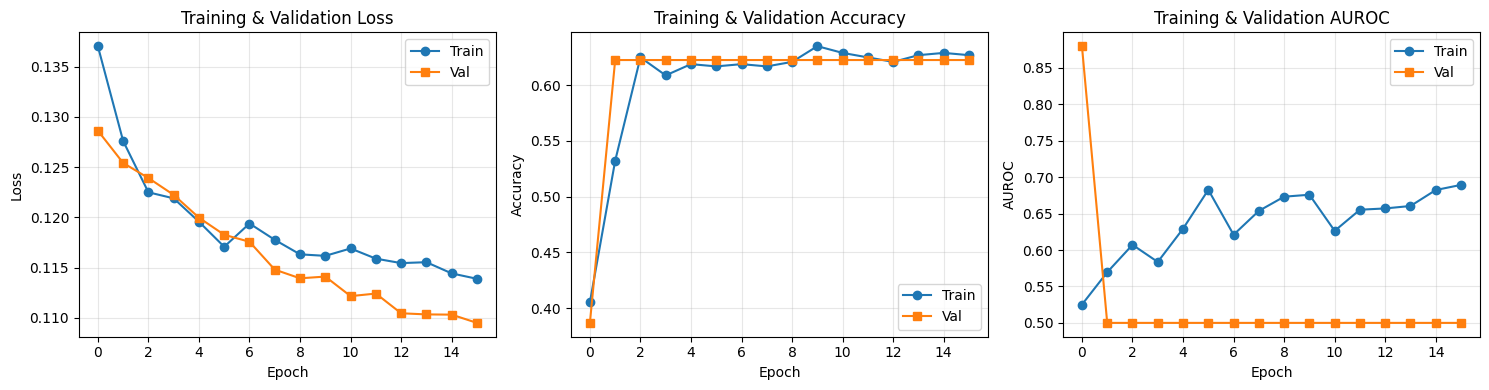

✅ Gráficos guardados: training_curves.png


In [22]:
# ============================================================================
# VISUALIZACIÓN
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Val', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', marker='o')
axes[1].plot(history['val_acc'], label='Val', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUROC
axes[2].plot(history['train_auc'], label='Train', marker='o')
axes[2].plot(history['val_auc'], label='Val', marker='s')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUROC')
axes[2].set_title('Training & Validation AUROC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráficos guardados: training_curves.png")

🔍 EVALUACIÓN DETALLADA DEL MODELO


/tmp/ipython-input-4133498866.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data, labels=labels, patch_artist=True,



📊 MÉTRICAS GLOBALES (threshold=0.5):
   Loss:     0.1286
   Accuracy: 0.387
   AUROC:    0.880
   Recall:   1.000

📈 DISTRIBUCIÓN DE PREDICCIONES

🔢 Estadísticas de probabilidades:
   Min:    0.4856
   Max:    0.5126
   Mean:   0.5079
   Median: 0.5094
   Std:    0.0037

📊 Percentiles:
   P10: 0.5035
   P25: 0.5053
   P50: 0.5094
   P75: 0.5103
   P90: 0.5111
   P95: 0.5114
   P99: 0.5122

📊 CONFUSION MATRIX (threshold=0.5)

🎯 Predicciones binarias:
   Predice Normal: 1 (0.9%)
   Predice Attack: 105 (99.1%)

   Confusion Matrix:
   ┌─────────────────────────────┐
   │         Predicted           │
   │      Normal    Attack       │
   ├─────────────────────────────┤
   │ True  │                     │
   │ Normal│     1        65      │
   │ Attack│     0        40      │
   └─────────────────────────────┘

📋 Desglose:
   True Negatives  (TN): 1 (Normal correctos)
   False Positives (FP): 65 (Normal predichos como Attack)
   False Negatives (FN): 0 (Attack predichos como Normal) ⚠️
   

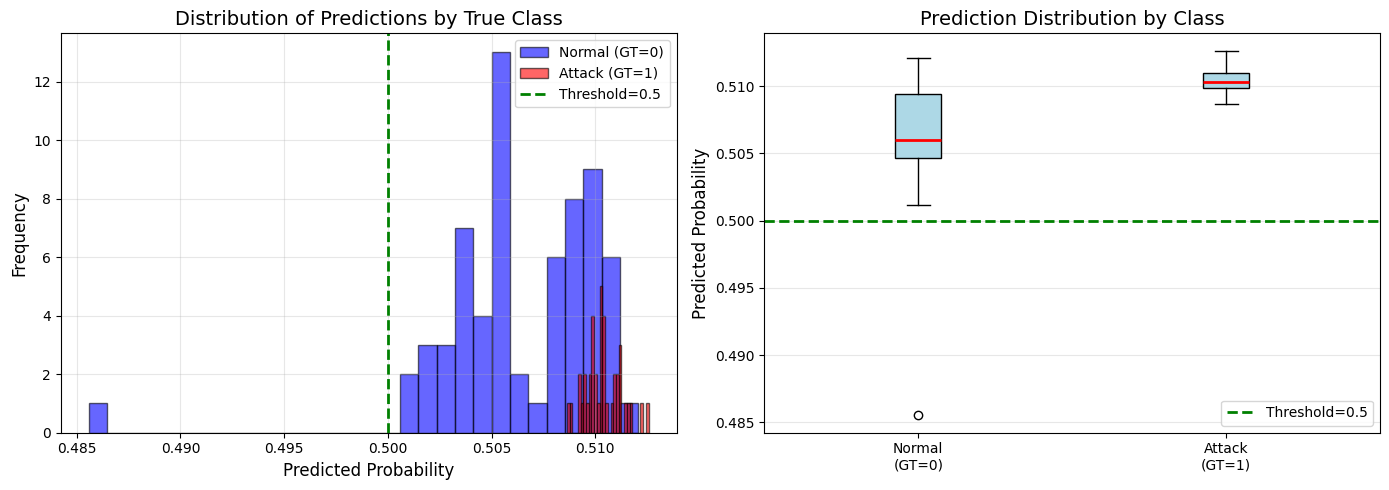


✅ Gráfico guardado: validation_analysis.png

📈 ROC CURVE ANALYSIS

🎯 Threshold óptimo (Youden):
   Threshold:  0.5092
   TPR:        0.950
   FPR:        0.288
   J-score:    0.662


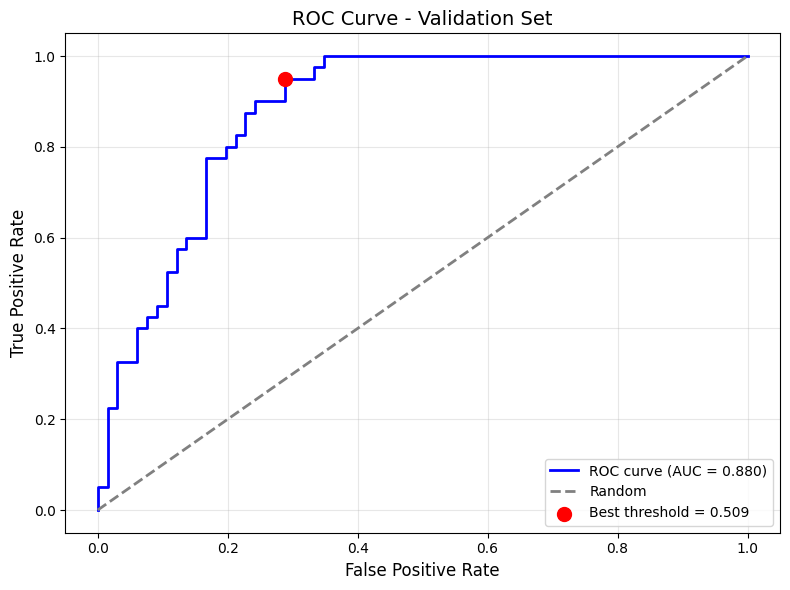


✅ Gráfico guardado: roc_curve.png

🎯 EVALUACIÓN CON THRESHOLD ÓPTIMO (0.509)

   Confusion Matrix:
   ┌─────────────────────────────┐
   │         Predicted           │
   │      Normal    Attack       │
   ├─────────────────────────────┤
   │ True  │                     │
   │ Normal│    47        19      │
   │ Attack│     3        37      │
   └─────────────────────────────┘

📊 Métricas con threshold óptimo:
   Accuracy:  0.792
   Precision: 0.661
   Recall:    0.925
   F1-Score:  0.771

📊 COMPARACIÓN: THRESHOLD 0.5 vs ÓPTIMO

   Metric  Threshold=0.5  Threshold=0.509
Threshold       0.500000         0.509212
 Accuracy       0.386792         0.792453
Precision       0.380952         0.660714
   Recall       1.000000         0.925000
 F1-Score       0.551724         0.770833
       TP      40.000000        37.000000
       FP      65.000000        19.000000
       FN       0.000000         3.000000
       TN       1.000000        47.000000

✅ Threshold óptimo (0.509) es MEJOR
   Mej

In [26]:
# ============================================================================
# EVALUACIÓN DETALLADA EN VALIDACIÓN
# ============================================================================

print("="*70)
print("🔍 EVALUACIÓN DETALLADA DEL MODELO")
print("="*70)

# Cargar el mejor modelo
model.load_state_dict(torch.load('best_model_focal.pt'))
model.eval()

# Evaluar con la función eval_epoch_v2
val_loss, val_acc, val_auc, val_recall, val_preds, val_labels = eval_epoch_v2(
    model, val_loader, criterion
)

# Convertir a arrays
val_preds_array = np.array(val_preds)
val_labels_array = np.array(val_labels)

print(f"\n📊 MÉTRICAS GLOBALES (threshold=0.5):")
print(f"   Loss:     {val_loss:.4f}")
print(f"   Accuracy: {val_acc:.3f}")
print(f"   AUROC:    {val_auc:.3f}")
print(f"   Recall:   {val_recall:.3f}")

# ============================================================================
# ANÁLISIS DE PREDICCIONES
# ============================================================================

print(f"\n" + "="*70)
print(f"📈 DISTRIBUCIÓN DE PREDICCIONES")
print(f"="*70)

print(f"\n🔢 Estadísticas de probabilidades:")
print(f"   Min:    {val_preds_array.min():.4f}")
print(f"   Max:    {val_preds_array.max():.4f}")
print(f"   Mean:   {val_preds_array.mean():.4f}")
print(f"   Median: {np.median(val_preds_array):.4f}")
print(f"   Std:    {val_preds_array.std():.4f}")

# Percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
print(f"\n📊 Percentiles:")
for p in percentiles:
    val = np.percentile(val_preds_array, p)
    print(f"   P{p:02d}: {val:.4f}")

# ============================================================================
# CONFUSION MATRIX (threshold = 0.5)
# ============================================================================

print(f"\n" + "="*70)
print(f"📊 CONFUSION MATRIX (threshold=0.5)")
print(f"="*70)

preds_binary = (val_preds_array > 0.5).astype(int)

# Contar predicciones
unique, counts = np.unique(preds_binary, return_counts=True)
print(f"\n🎯 Predicciones binarias:")
for u, c in zip(unique, counts):
    label = "Normal" if u == 0 else "Attack"
    print(f"   Predice {label}: {c} ({c/len(preds_binary)*100:.1f}%)")

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(val_labels_array, preds_binary)

print(f"\n   Confusion Matrix:")
print(f"   ┌─────────────────────────────┐")
print(f"   │         Predicted           │")
print(f"   │      Normal    Attack       │")
print(f"   ├─────────────────────────────┤")
print(f"   │ True  │                     │")
print(f"   │ Normal│  {cm[0,0]:>4}      {cm[0,1]:>4}      │")
print(f"   │ Attack│  {cm[1,0]:>4}      {cm[1,1]:>4}      │")
print(f"   └─────────────────────────────┘")

# Métricas detalladas
tn, fp, fn, tp = cm.ravel()

print(f"\n📋 Desglose:")
print(f"   True Negatives  (TN): {tn} (Normal correctos)")
print(f"   False Positives (FP): {fp} (Normal predichos como Attack)")
print(f"   False Negatives (FN): {fn} (Attack predichos como Normal) ⚠️")
print(f"   True Positives  (TP): {tp} (Attack correctos)")

# Métricas derivadas
precision, recall, f1, _ = precision_recall_fscore_support(
    val_labels_array, preds_binary, average='binary', zero_division=0
)

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\n📊 Métricas detalladas:")
print(f"   Precision:   {precision:.3f} (de los predichos Attack, % correctos)")
print(f"   Recall:      {recall:.3f} (de los Attack reales, % detectados)")
print(f"   F1-Score:    {f1:.3f} (media harmónica Prec/Recall)")
print(f"   Specificity: {specificity:.3f} (de los Normal reales, % correctos)")
print(f"   FPR:         {fpr:.3f} (False Positive Rate)")
print(f"   FNR:         {fnr:.3f} (False Negative Rate)")

# ============================================================================
# ANÁLISIS POR CLASE
# ============================================================================

print(f"\n" + "="*70)
print(f"🎯 ANÁLISIS POR CLASE")
print(f"="*70)

# Separar predicciones por clase real
normal_preds = val_preds_array[val_labels_array == 0]
attack_preds = val_preds_array[val_labels_array == 1]

print(f"\n📊 CLASE NORMAL (Ground Truth = 0):")
print(f"   Cantidad:     {len(normal_preds)}")
print(f"   Mean pred:    {normal_preds.mean():.4f}")
print(f"   Median pred:  {np.median(normal_preds):.4f}")
print(f"   Std pred:     {normal_preds.std():.4f}")
print(f"   % pred > 0.5: {(normal_preds > 0.5).sum() / len(normal_preds) * 100:.1f}%")

print(f"\n📊 CLASE ATTACK (Ground Truth = 1):")
print(f"   Cantidad:     {len(attack_preds)}")
print(f"   Mean pred:    {attack_preds.mean():.4f}")
print(f"   Median pred:  {np.median(attack_preds):.4f}")
print(f"   Std pred:     {attack_preds.std():.4f}")
print(f"   % pred > 0.5: {(attack_preds > 0.5).sum() / len(attack_preds) * 100:.1f}%")

print(f"\n🎯 Separación:")
diff = attack_preds.mean() - normal_preds.mean()
print(f"   Diferencia de medias: {diff:.4f}")
if diff > 0.2:
    print(f"   ✅ Buena separación (modelo distingue clases)")
elif diff > 0.1:
    print(f"   ⚠️  Separación moderada")
else:
    print(f"   ❌ Poca separación (modelo confunde clases)")

# ============================================================================
# HISTOGRAMA DE PREDICCIONES
# ============================================================================

print(f"\n" + "="*70)
print(f"📊 HISTOGRAMA DE PREDICCIONES")
print(f"="*70)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Histograma por clase
axes[0].hist(normal_preds, bins=30, alpha=0.6, label='Normal (GT=0)', color='blue', edgecolor='black')
axes[0].hist(attack_preds, bins=30, alpha=0.6, label='Attack (GT=1)', color='red', edgecolor='black')
axes[0].axvline(0.5, color='green', linestyle='--', linewidth=2, label='Threshold=0.5')
axes[0].set_xlabel('Predicted Probability', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Predictions by True Class', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subplot 2: Boxplot
data = [normal_preds, attack_preds]
labels = ['Normal\n(GT=0)', 'Attack\n(GT=1)']
axes[1].boxplot(data, labels=labels, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].axhline(0.5, color='green', linestyle='--', linewidth=2, label='Threshold=0.5')
axes[1].set_ylabel('Predicted Probability', fontsize=12)
axes[1].set_title('Prediction Distribution by Class', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('validation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráfico guardado: validation_analysis.png")

# ============================================================================
# ROC CURVE
# ============================================================================

from sklearn.metrics import roc_curve

print(f"\n" + "="*70)
print(f"📈 ROC CURVE ANALYSIS")
print(f"="*70)

fpr_roc, tpr_roc, thresholds_roc = roc_curve(val_labels_array, val_preds_array)

# Encontrar mejor threshold (Youden's J statistic)
j_scores = tpr_roc - fpr_roc
best_idx = np.argmax(j_scores)
best_threshold = thresholds_roc[best_idx]

print(f"\n🎯 Threshold óptimo (Youden):")
print(f"   Threshold:  {best_threshold:.4f}")
print(f"   TPR:        {tpr_roc[best_idx]:.3f}")
print(f"   FPR:        {fpr_roc[best_idx]:.3f}")
print(f"   J-score:    {j_scores[best_idx]:.3f}")

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_roc, tpr_roc, color='blue', lw=2, label=f'ROC curve (AUC = {val_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random')
plt.scatter(fpr_roc[best_idx], tpr_roc[best_idx], color='red', s=100, zorder=5,
            label=f'Best threshold = {best_threshold:.3f}')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Validation Set', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráfico guardado: roc_curve.png")

# ============================================================================
# EVALUACIÓN CON THRESHOLD ÓPTIMO
# ============================================================================

print(f"\n" + "="*70)
print(f"🎯 EVALUACIÓN CON THRESHOLD ÓPTIMO ({best_threshold:.3f})")
print(f"="*70)

preds_binary_opt = (val_preds_array > best_threshold).astype(int)

cm_opt = confusion_matrix(val_labels_array, preds_binary_opt)
tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

print(f"\n   Confusion Matrix:")
print(f"   ┌─────────────────────────────┐")
print(f"   │         Predicted           │")
print(f"   │      Normal    Attack       │")
print(f"   ├─────────────────────────────┤")
print(f"   │ True  │                     │")
print(f"   │ Normal│  {cm_opt[0,0]:>4}      {cm_opt[0,1]:>4}      │")
print(f"   │ Attack│  {cm_opt[1,0]:>4}      {cm_opt[1,1]:>4}      │")
print(f"   └─────────────────────────────┘")

precision_opt, recall_opt, f1_opt, _ = precision_recall_fscore_support(
    val_labels_array, preds_binary_opt, average='binary', zero_division=0
)

acc_opt = accuracy_score(val_labels_array, preds_binary_opt)

print(f"\n📊 Métricas con threshold óptimo:")
print(f"   Accuracy:  {acc_opt:.3f}")
print(f"   Precision: {precision_opt:.3f}")
print(f"   Recall:    {recall_opt:.3f}")
print(f"   F1-Score:  {f1_opt:.3f}")

# ============================================================================
# COMPARACIÓN THRESHOLD 0.5 vs ÓPTIMO
# ============================================================================

print(f"\n" + "="*70)
print(f"📊 COMPARACIÓN: THRESHOLD 0.5 vs ÓPTIMO")
print(f"="*70)

comparison = pd.DataFrame({
    'Metric': ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1-Score',
               'TP', 'FP', 'FN', 'TN'],
    'Threshold=0.5': [0.5, val_acc, precision, recall, f1, tp, fp, fn, tn],
    f'Threshold={best_threshold:.3f}': [best_threshold, acc_opt, precision_opt,
                                          recall_opt, f1_opt, tp_opt, fp_opt,
                                          fn_opt, tn_opt]
})

print(f"\n{comparison.to_string(index=False)}")

# Identificar cuál es mejor
if f1_opt > f1:
    print(f"\n✅ Threshold óptimo ({best_threshold:.3f}) es MEJOR")
    print(f"   Mejora F1: {f1_opt - f1:.3f} ({(f1_opt - f1)/f1*100:.1f}%)")
else:
    print(f"\n⚠️  Threshold 0.5 funciona bien")

# ============================================================================
# CASOS PROBLEMÁTICOS
# ============================================================================

print(f"\n" + "="*70)
print(f"🔍 ANÁLISIS DE ERRORES")
print(f"="*70)

# False Negatives (ataques NO detectados)
fn_indices = np.where((val_labels_array == 1) & (preds_binary == 0))[0]
print(f"\n❌ FALSE NEGATIVES (Attack predicho como Normal):")
print(f"   Total: {len(fn_indices)}")

if len(fn_indices) > 0:
    fn_probs = val_preds_array[fn_indices]
    print(f"   Probabilidades:")
    print(f"      Min:  {fn_probs.min():.4f}")
    print(f"      Max:  {fn_probs.max():.4f}")
    print(f"      Mean: {fn_probs.mean():.4f}")
    print(f"\n   ⚠️  Estos son ataques que el modelo NO detectó")
    print(f"      (probabilidades < 0.5)")

# False Positives (normales predichos como ataques)
fp_indices = np.where((val_labels_array == 0) & (preds_binary == 1))[0]
print(f"\n❌ FALSE POSITIVES (Normal predicho como Attack):")
print(f"   Total: {len(fp_indices)}")

if len(fp_indices) > 0:
    fp_probs = val_preds_array[fp_indices]
    print(f"   Probabilidades:")
    print(f"      Min:  {fp_probs.min():.4f}")
    print(f"      Max:  {fp_probs.max():.4f}")
    print(f"      Mean: {fp_probs.mean():.4f}")
    print(f"\n   ⚠️  Falsos positivos (alertas falsas)")

# ============================================================================
# RESUMEN FINAL
# ============================================================================

print(f"\n" + "="*70)
print(f"✅ RESUMEN DE EVALUACIÓN")
print(f"="*70)

print(f"\n🎯 Resultados clave:")
print(f"   AUROC:           {val_auc:.3f}")
print(f"   F1 (t=0.5):      {f1:.3f}")
print(f"   F1 (t óptimo):   {f1_opt:.3f}")
print(f"   Recall (t=0.5):  {recall:.3f}")
print(f"   Recall (óptimo): {recall_opt:.3f}")

print(f"\n📊 Distribución:")
print(f"   Normal mean prob: {normal_preds.mean():.3f}")
print(f"   Attack mean prob: {attack_preds.mean():.3f}")
print(f"   Separación:       {diff:.3f}")

if val_auc > 0.85 and recall_opt > 0.6:
    print(f"\n✅ MODELO FUNCIONA BIEN")
    print(f"   - Alta capacidad de discriminación (AUC > 0.85)")
    print(f"   - Detecta mayoría de ataques (Recall > 0.6)")
elif val_auc > 0.75:
    print(f"\n⚠️  MODELO FUNCIONA MODERADAMENTE")
    print(f"   - Capacidad de discriminación aceptable")
    print(f"   - Pero puede mejorar")
else:
    print(f"\n❌ MODELO NECESITA MEJORAS")
    print(f"   - Baja capacidad de discriminación")
    print(f"   - Revisar features, arquitectura, o datos")

print(f"\n{'='*70}")